# SL/TP Regressor - Exploration & Evaluation

Tests the pipeline on a configurable subset to verify correctness and visualise results.

**Sections:** 1. Setup  2. Session entries  3. Oracle targets  4. Features  5. Optuna  6. Diagnostics  7. Final model  8. Predictions  9. PnL  10. Breakdown  11. Importances  12. Summary

In [1]:
import sys, pathlib, os
_here = pathlib.Path().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / 'pyproject.toml').exists()), _here)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
os.chdir(_root)  # ensure relative data paths resolve correctly
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import optuna
from sklearn.model_selection import TimeSeriesSplit
from tqdm.auto import tqdm
from src.pipelines.sl_tp_regressor import (
    load_m1, session_entry_positions, build_forward_matrices,
    simulate, simulate_per_trade, load_or_compute_oracle_targets,
    build_feature_matrix, make_lgbm_objective, _clip_predictions,
    SESSION_HOURS, SL_MIN, SL_MAX, TP_MIN, TP_MAX, MAX_BARS, PIP, SEED,
)
import src.pipelines.sl_tp_regressor as _pipe
import lightgbm as lgb
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 4)})
print(f'Repo root : {_root}')
print('imports OK')

Repo root : C:\Projects\My\Re-Diggn
imports OK


In [15]:
# --- Configure run here ---
SUBSET_START   = '2010-01-01'
SUBSET_END     = '2024-12-31'
N_TRIALS_NB    = 30
N_CV_SPLITS    = 5
TEST_FRAC      = 0.20
FEATURE_SET    = 'all'   # 'situational' | 'indicators' | 'fundamental' | all
LGBM_DEVICE    = 'cpu'           # 'cpu' | 'gpu' (OpenCL) | 'cuda' (Linux+custom build only)
LGBM_DEVICE_ID = 0
# Patch module so make_lgbm_objective uses notebook device
_pipe.LGBM_DEVICE    = LGBM_DEVICE
_pipe.LGBM_DEVICE_ID = LGBM_DEVICE_ID
print(f'Subset: {SUBSET_START} -> {SUBSET_END}')
print(f'Feature set: {FEATURE_SET}  |  Device: {LGBM_DEVICE}')
print(f'Optuna: {N_TRIALS_NB} trials x {N_CV_SPLITS} folds')

Subset: 2010-01-01 -> 2024-12-31
Feature set: all  |  Device: cpu
Optuna: 30 trials x 5 folds


## 1. Data loading

In [3]:
df_full = load_m1()
df = df_full.loc[SUBSET_START:SUBSET_END].copy()
print(f'Full dataset : {len(df_full):,} bars')
print(f'Subset       : {len(df):,} bars  ({df.index[0].date()} -> {df.index[-1].date()})')
df.head(3)

Full dataset : 7,319,374 bars
Subset       : 5,557,514 bars  (2010-01-04 -> 2024-12-31)


,open,high,low,close,tick_volume,volume,spread,swap_long,swap_short,target_opt_tp_buy_sl_5,...,fund_ev_nfp_surprise,fund_ev_cpi_time_since,fund_ev_cpi_flag,fund_ev_cpi_surprise,fund_ev_gdp_time_since,fund_ev_gdp_flag,fund_ev_gdp_surprise,fund_ev_density_24h,fund_ev_density_7d,fund_ev_time_to_next
timestamp,,,,,,,,,,,,,,,,,,,,,
2010-01-04 00:00:00+00:00,1.43259,1.43259,1.43213,1.43228,27,0,20,0.008,-0.0037,9,...,NaN,5.145845,False,NaN,12.437500,False,NaN,1.0,4.0,0.625000
2010-01-04 00:01:00+00:00,1.43222,1.43242,1.43222,1.43242,12,0,20,0.008,-0.0037,7,...,NaN,5.146539,False,NaN,12.438194,False,NaN,1.0,4.0,0.624306
2010-01-04 00:02:00+00:00,1.43241,1.43244,1.43231,1.43235,23,0,20,0.008,-0.0037,8,...,NaN,5.147234,False,NaN,12.438889,False,NaN,1.0,4.0,0.623611


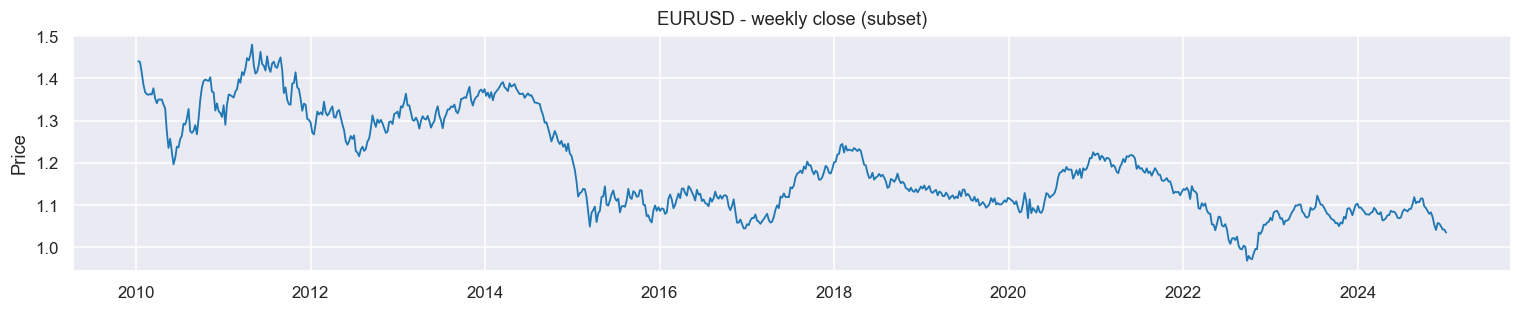

In [4]:
weekly = df['close'].resample('W').last()
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(weekly.index, weekly.values, lw=1.2)
ax.set_title('EURUSD - weekly close (subset)')
ax.set_ylabel('Price')
plt.tight_layout(); plt.show()

## 2. Session entry analysis

Total:1,598,591  Train:1,278,872  Test:319,719
Train 2010-01-04 -> 2021-12-16
Test  2021-12-16 -> 2024-12-31


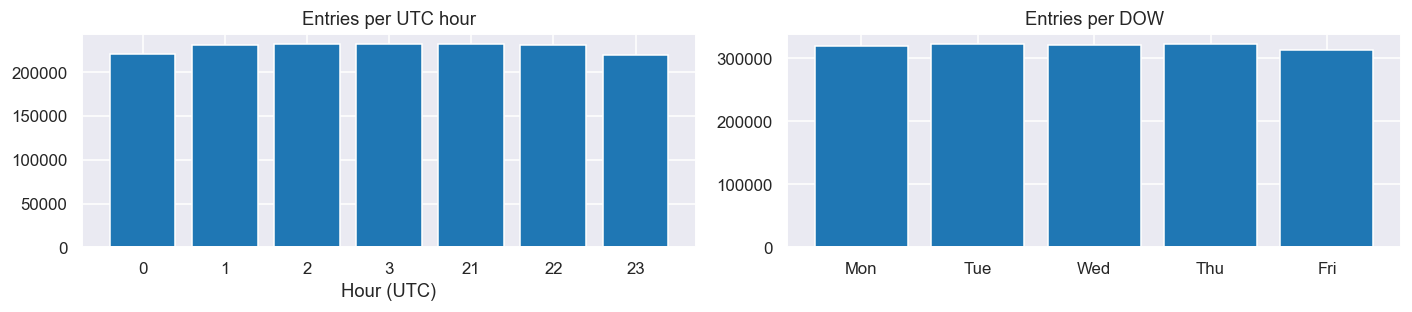

In [5]:
pos      = session_entry_positions(df, SESSION_HOURS)
entry_ts = pd.DatetimeIndex(df.index[pos])
split    = int(len(pos) * (1 - TEST_FRAC))
tr_pos, te_pos = pos[:split], pos[split:]
print(f'Total:{len(pos):,}  Train:{len(tr_pos):,}  Test:{len(te_pos):,}')
print(f'Train {df.index[tr_pos[0]].date()} -> {df.index[tr_pos[-1]].date()}')
print(f'Test  {df.index[te_pos[0]].date()} -> {df.index[te_pos[-1]].date()}')
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
hc = pd.Series(entry_ts.hour).value_counts().sort_index()
axes[0].bar(hc.index.astype(str), hc.values)
axes[0].set_title('Entries per UTC hour'); axes[0].set_xlabel('Hour (UTC)')
dc = pd.Series(entry_ts.dayofweek).value_counts().sort_index()
axes[1].bar([['Mon','Tue','Wed','Thu','Fri'][d] for d in dc.index], dc.values)
axes[1].set_title('Entries per DOW')
plt.tight_layout(); plt.show()

## 3. Oracle targets - per-entry optimal SL/TP

In [6]:
print('Building forward matrices for subset entries...')
H_all, L_all, C_all, E_all, SP_all = build_forward_matrices(df, pos)
H_tr,  L_tr,  C_tr,  E_tr,  SP_tr  = H_all[:split], L_all[:split], C_all[:split], E_all[:split], SP_all[:split]
H_te,  L_te,  C_te,  E_te,  SP_te  = H_all[split:], L_all[split:], C_all[split:], E_all[split:], SP_all[split:]
print(f'  all {H_all.shape}  train {H_tr.shape}  test {H_te.shape}')

Building forward matrices for subset entries...
  all (1598591, 480)  train (1278872, 480)  test (319719, 480)


In [7]:
# Oracle computed once for the full dataset; parquet cache is reused for any subset.
# Only recomputes when SL/TP ranges, MAX_BARS, or SESSION_HOURS change.
print('Loading oracle targets from cache (or computing for full dataset)...')
oracle_df  = load_or_compute_oracle_targets(df_full)
entry_ts   = pd.DatetimeIndex(df.index[pos])
oracle_sub = oracle_df.set_index('timestamp').loc[entry_ts]
y_sl_all   = oracle_sub['oracle_sl'].to_numpy(dtype='int16')
y_tp_all   = oracle_sub['oracle_tp'].to_numpy(dtype='int16')
pnl_all    = oracle_sub['oracle_pnl'].to_numpy(dtype='float32')
y_sl_tr, y_tp_tr, oracle_pnl_tr = y_sl_all[:split], y_tp_all[:split], pnl_all[:split]
y_sl_te, y_tp_te, oracle_pnl_te = y_sl_all[split:], y_tp_all[split:], pnl_all[split:]
print(f'Train oracle avg : {oracle_pnl_tr.mean():+.2f} pips/trade')
print(f'Test  oracle avg : {oracle_pnl_te.mean():+.2f} pips/trade')

Loading oracle targets from cache (or computing for full dataset)...
  Oracle cache: grid params changed — recomputing full dataset.
  Running oracle grid search: 2,066,258 entries × 1,296 combos (5–40 × 5–40 pips)…


Oracle grid:   0%|          | 0/2067 [00:00<?, ?chunk/s]

  Oracle targets saved → data\processed\oracle_targets_sl_tp.parquet  (2,066,258 rows)
Train oracle avg : +20.75 pips/trade
Test  oracle avg : +16.22 pips/trade


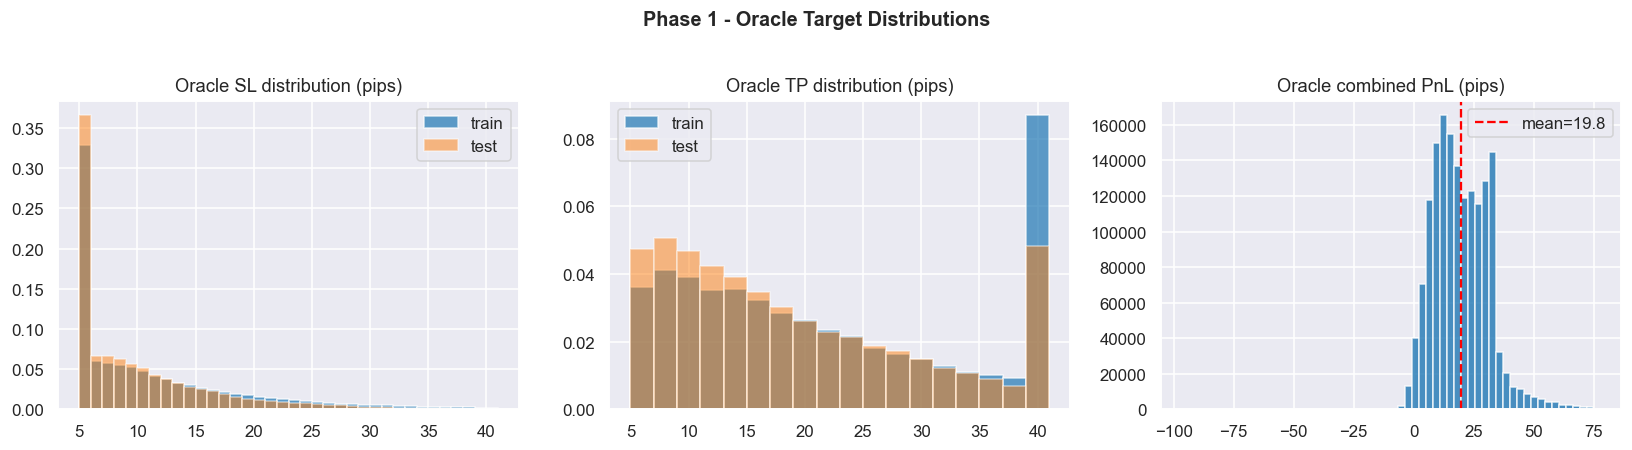

SL  mean=11.2 std=7.6 | TP mean=21.2 std=11.8


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(y_sl_tr, bins=range(SL_MIN, SL_MAX+2), alpha=0.7, label='train', density=True)
axes[0].hist(y_sl_te, bins=range(SL_MIN, SL_MAX+2), alpha=0.5, label='test',  density=True)
axes[0].set_title('Oracle SL distribution (pips)'); axes[0].legend()
axes[1].hist(y_tp_tr, bins=range(TP_MIN, TP_MAX+2, 2), alpha=0.7, label='train', density=True)
axes[1].hist(y_tp_te, bins=range(TP_MIN, TP_MAX+2, 2), alpha=0.5, label='test',  density=True)
axes[1].set_title('Oracle TP distribution (pips)'); axes[1].legend()
all_pnl = np.concatenate([oracle_pnl_tr, oracle_pnl_te])
axes[2].hist(all_pnl, bins=60, alpha=0.8)
axes[2].axvline(all_pnl.mean(), color='red', lw=1.5, linestyle='--', label=f'mean={all_pnl.mean():.1f}')
axes[2].set_title('Oracle combined PnL (pips)'); axes[2].legend()
plt.suptitle('Phase 1 - Oracle Target Distributions', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'SL  mean={y_sl_tr.mean():.1f} std={y_sl_tr.std():.1f} | TP mean={y_tp_tr.mean():.1f} std={y_tp_tr.std():.1f}')

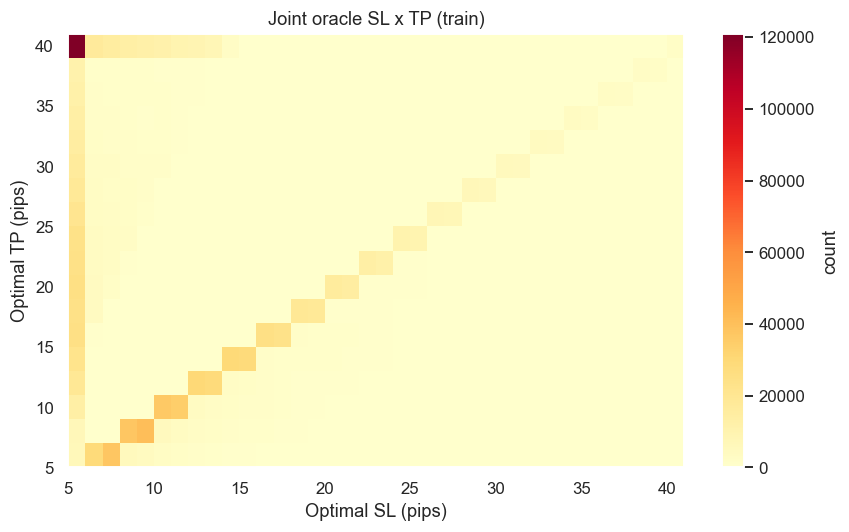

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
h = ax.hist2d(y_sl_tr.astype(int), y_tp_tr.astype(int),
              bins=[range(SL_MIN, SL_MAX+2), range(TP_MIN, TP_MAX+2, 2)], cmap='YlOrRd')
plt.colorbar(h[3], ax=ax, label='count')
ax.set_xlabel('Optimal SL (pips)'); ax.set_ylabel('Optimal TP (pips)')
ax.set_title('Joint oracle SL x TP (train)')
plt.tight_layout(); plt.show()

## 4. Feature engineering

In [10]:
print(f'Building features - {FEATURE_SET!r}...')
X_tr_df = build_feature_matrix(df, tr_pos, SP_tr, FEATURE_SET)
X_te_df = build_feature_matrix(df, te_pos, SP_te, FEATURE_SET)
feature_names = list(X_tr_df.columns)
X_tr = X_tr_df.to_numpy(dtype=np.float32)
X_te = X_te_df.to_numpy(dtype=np.float32)
print(f'  Train {X_tr.shape}  Test {X_te.shape}')
print(f'  NaN: {np.isnan(X_tr).sum()} train | {np.isnan(X_te).sum()} test')
X_tr_df.describe().round(4)

Building features - 'all'...
  [situational] computing situ_ features on full dataframe...


situ:windows:   0%|          | 0/5 [00:00<?, ?it/s]

situ:atr:   0%|          | 0/2 [00:00<?, ?it/s]

situ:bbands:   0%|          | 0/2 [00:00<?, ?it/s]

situ:rsi:   0%|          | 0/2 [00:00<?, ?it/s]

...

situ:rsi:   0%|          | 0/2 [00:00<?, ?it/s]

situ:adx:   0%|          | 0/2 [00:00<?, ?it/s]

situ:sma:   0%|          | 0/5 [00:00<?, ?it/s]

  [indicators] computing SMA/MinMax/Stoch features on full dataframe...
  Train (1278872, 184)  Test (319719, 184)
  NaN: 6393418 train | 1596184 test


,situ_ret1m,situ_body,situ_upper_wick,situ_lower_wick,situ_true_range,situ_rv_std_5,situ_range_5,situ_pos_in_range_5,situ_dir_changes_5,situ_abs_ret_sum_5,...,quarter_4,monthweek_business_0,monthweek_business_1,monthweek_business_2,monthweek_business_3,monthweek_business_4,fund_rate_diff,fund_rate_diff_change,fund_carry_rank,fund_rate_diff_time_since
count,1.278871e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278870e+06,1.278868e+06,1.278613e+06,1.278868e+06,1.278867e+06,...,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06,1.278872e+06
mean,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-04,1.000000e-04,3.000000e-04,4.977000e-01,2.969100e+00,3.000000e-04,...,2.450000e-01,2.293000e-01,2.329000e-01,2.323000e-01,2.264000e-01,7.910000e-02,-7.214000e-01,-2.000000e-04,7.760000e-02,2.159655e+02
std,1.000000e-04,1.000000e-04,1.000000e-04,1.000000e-04,1.000000e-04,1.000000e-04,3.000000e-04,3.198000e-01,1.142300e+00,3.000000e-04,...,4.301000e-01,4.204000e-01,4.227000e-01,4.223000e-01,4.185000e-01,2.698000e-01,9.079000e-01,2.750000e-02,2.676000e-01,1.993039e+02
min,-1.510000e-02,-6.000000e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.775000e+00,-2.500000e-01,0.000000e+00,0.000000e+00
25%,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-04,0.000000e+00,2.000000e-04,2.081000e-01,2.000000e+00,1.000000e-04,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.275000e+00,0.000000e+00,0.000000e+00,5.387780e+01
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-04,1.000000e-04,3.000000e-04,5.000000e-01,3.000000e+00,2.000000e-04,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.250000e-01,0.000000e+00,0.000000e+00,1.381049e+02
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-04,1.000000e-04,4.000000e-04,7.858000e-01,4.000000e+00,4.000000e-04,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.250000e-01,0.000000e+00,0.000000e+00,3.580320e+02
max,1.680000e-02,8.500000e-03,4.000000e-03,5.800000e-03,1.290000e-02,7.600000e-03,2.190000e-02,1.000000e+00,5.000000e+00,2.070000e-02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.250000e-01,1.000000e+00,1.000000e+00,7.349993e+02


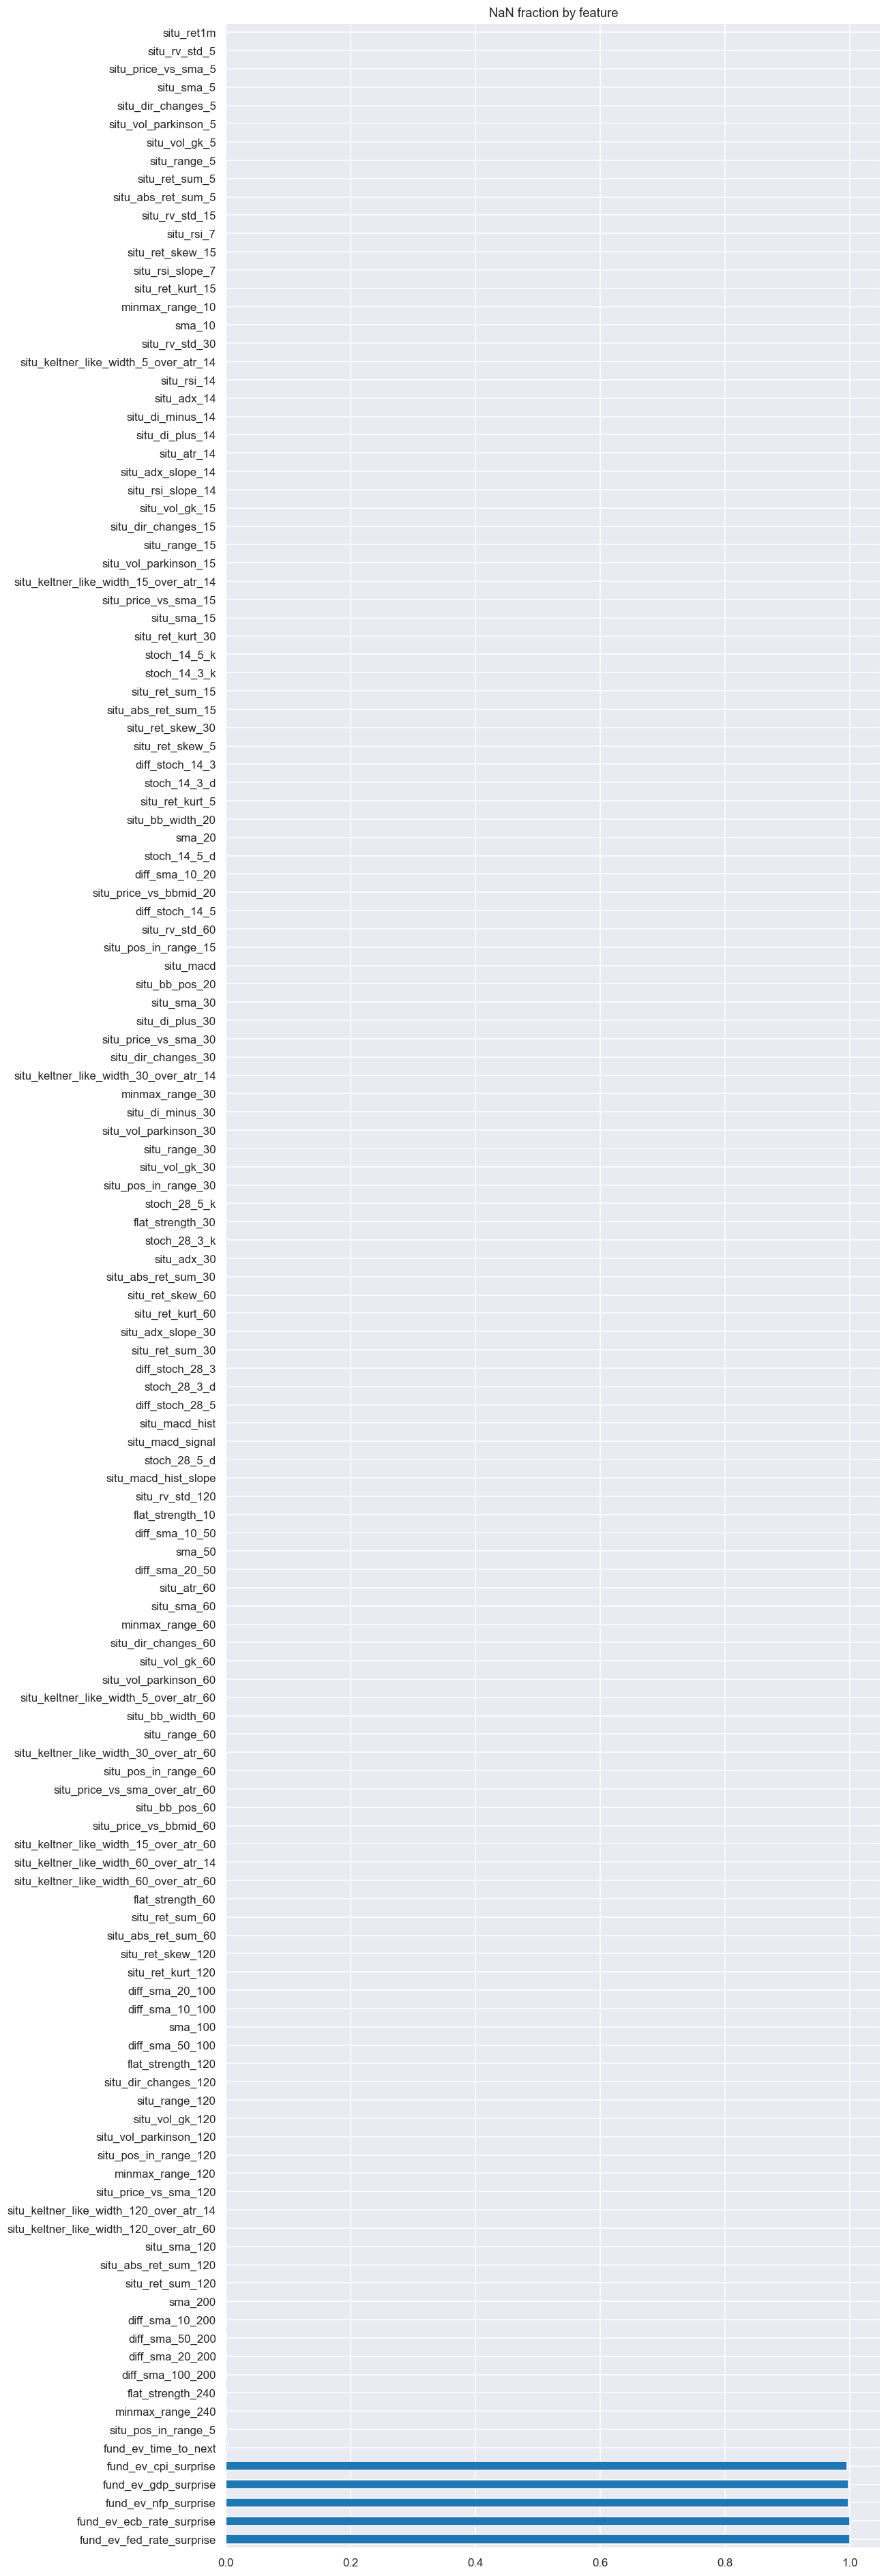

In [11]:
nan_frac = pd.Series(np.isnan(X_tr).mean(axis=0), index=feature_names)
nan_nz   = nan_frac[nan_frac > 0].sort_values(ascending=False)
if len(nan_nz):
    fig, ax = plt.subplots(figsize=(12, max(3, len(nan_nz)*0.25)))
    nan_nz.plot.barh(ax=ax); ax.set_title('NaN fraction by feature')
    plt.tight_layout(); plt.show()
else:
    print('No NaN in train matrix.')

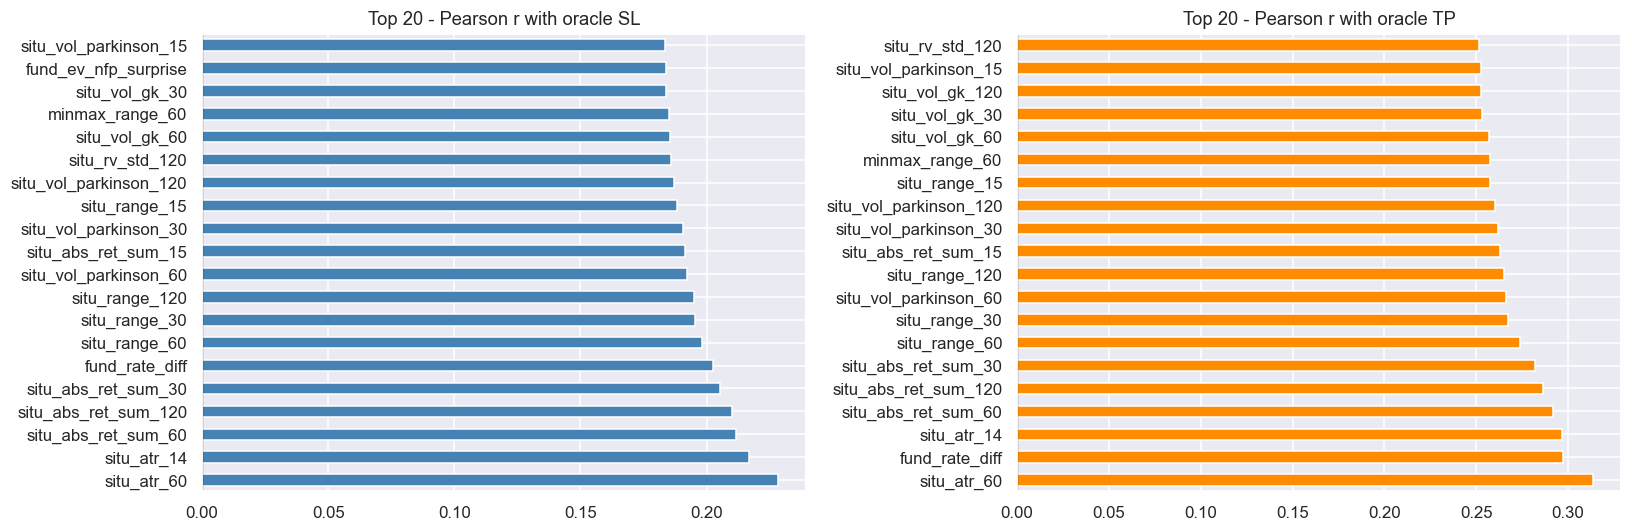

In [12]:
def _corr(X, y):
    return pd.Series(
        [np.corrcoef(X[:,i][~np.isnan(X[:,i])], y[~np.isnan(X[:,i])])[0,1]
         for i in range(X.shape[1])], index=feature_names
    ).sort_values(key=abs, ascending=False)
corr_sl = _corr(X_tr, y_sl_tr)
corr_tp = _corr(X_tr, y_tp_tr)
top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
corr_sl.head(top_n).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title(f'Top {top_n} - Pearson r with oracle SL'); axes[0].axvline(0, color='k', lw=0.8)
corr_tp.head(top_n).plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title(f'Top {top_n} - Pearson r with oracle TP'); axes[1].axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

## 5. Model training - Optuna + TSCV

In [13]:
tscv      = TimeSeriesSplit(n_splits=N_CV_SPLITS)
cv_splits = list(tscv.split(np.arange(len(tr_pos))))
print(f'TimeSeriesSplit: {N_CV_SPLITS} folds')
for i, (ti, vi) in enumerate(cv_splits):
    print(f'  fold {i+1}: train={len(ti):,}  val={len(vi):,}')

TimeSeriesSplit: 5 folds
  fold 1: train=213,147  val=213,145
  fold 2: train=426,292  val=213,145
  fold 3: train=639,437  val=213,145
  fold 4: train=852,582  val=213,145
  fold 5: train=1,065,727  val=213,145


In [16]:
study = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
trial_vals = []
pbar = tqdm(total=N_TRIALS_NB, desc='Optuna', unit='trial', dynamic_ncols=True)
def _cb(s, t):
    val = t.value if t.value is not None else float('nan')
    trial_vals.append(val)
    best = s.best_value if s.best_trial else float('nan')
    pbar.set_postfix(cv=f'{val:+.0f}', best=f'{best:+.0f}'); pbar.update(1)
study.optimize(
    make_lgbm_objective(X_tr, y_sl_tr, y_tp_tr, H_tr, L_tr, C_tr, E_tr, SP_tr, cv_splits),
    n_trials=N_TRIALS_NB, show_progress_bar=False, callbacks=[_cb])
pbar.close()
print(f'Best CV PnL : {study.best_value:+,.1f} pips')
print(f'Best params : {study.best_params}')

Optuna:   0%|          | 0/30 [00:00<?, ?trial/s]

Best CV PnL : -555,120.0 pips
Best params : {'n_estimators': 593, 'learning_rate': 0.018282423239160996, 'max_depth': 5, 'num_leaves': 82, 'min_child_samples': 91, 'subsample': 0.6387548274607867, 'colsample_bytree': 0.8853132243279799, 'reg_alpha': 7.495953242549362e-07, 'reg_lambda': 1.648254991114195e-08}


## 6. Optuna diagnostics

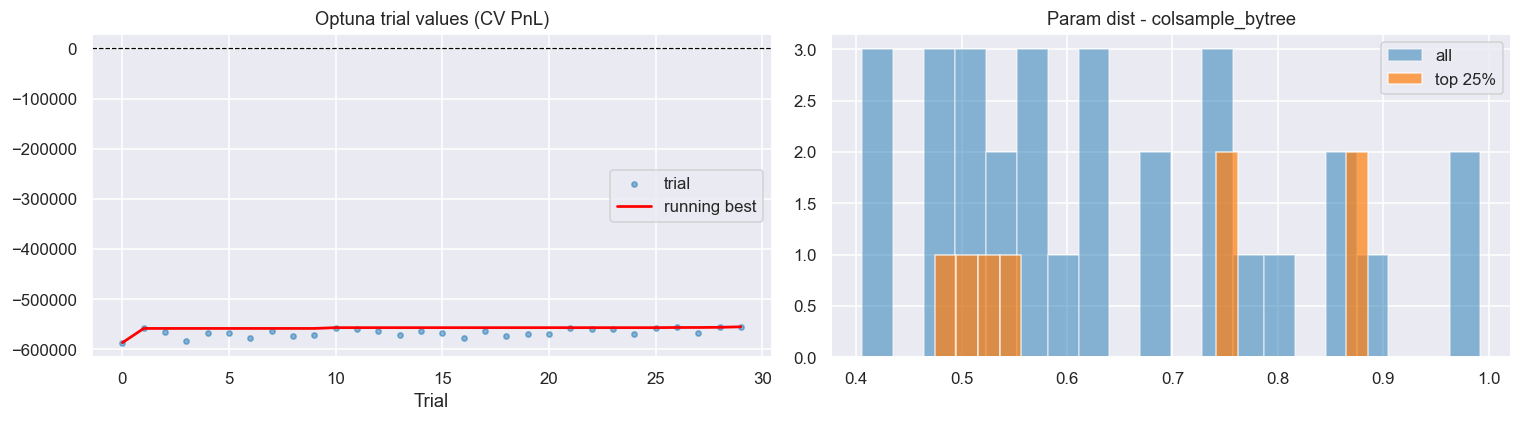

,number,value,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample
29,29,-555120.02500,0.885313,0.018282,5,91,593,82,7.495953e-07,1.648255e-08,0.638755
28,28,-556144.56250,0.873839,0.020114,5,88,668,101,9.909900e-07,4.502354e-08,0.644724
26,26,-556469.87500,0.749624,0.013906,5,94,1030,87,1.882354e-06,6.251129e-06,0.701880
10,10,-556804.40000,0.553266,0.010206,6,59,1468,122,4.327476e-05,2.059001e-04,0.845124
25,25,-557204.76250,0.751291,0.014188,5,58,1045,118,2.930044e-05,4.893527e-06,0.697422
1,1,-558368.01250,0.510043,0.010725,6,25,1208,109,5.472430e-06,5.282115e-04,0.590912
21,21,-558464.72500,0.530924,0.010914,6,60,1455,126,1.308447e-04,3.377110e-04,0.838125
23,23,-559758.40000,0.474412,0.013960,6,80,1269,127,4.140656e-05,3.843388e-05,0.908320
22,22,-559866.01875,0.555191,0.010488,6,68,1384,114,8.014127e-07,1.079549e-03,0.810107
11,11,-560414.02500,0.519964,0.010291,6,58,1498,124,1.487054e-04,2.242698e-04,0.851350


In [17]:
trials_df    = study.trials_dataframe()
running_best = pd.Series(trial_vals).cummax()
param_cols   = [c for c in trials_df.columns if c.startswith('params_')]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(range(len(trial_vals)), trial_vals, s=12, alpha=0.5, label='trial')
axes[0].plot(running_best.values, color='red', lw=1.8, label='running best')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Optuna trial values (CV PnL)'); axes[0].set_xlabel('Trial'); axes[0].legend()
if param_cols:
    thresh = trials_df['value'].quantile(0.75)
    top_df = trials_df[trials_df['value'] >= thresh]
    p = param_cols[0].replace('params_', '')
    axes[1].hist(trials_df[param_cols[0]], bins=20, alpha=0.5, label='all')
    axes[1].hist(top_df[param_cols[0]],   bins=20, alpha=0.7, label='top 25%')
    axes[1].set_title(f'Param dist - {p}'); axes[1].legend()
plt.tight_layout(); plt.show()
trials_df.sort_values('value', ascending=False).head(10)[['number', 'value'] + param_cols]

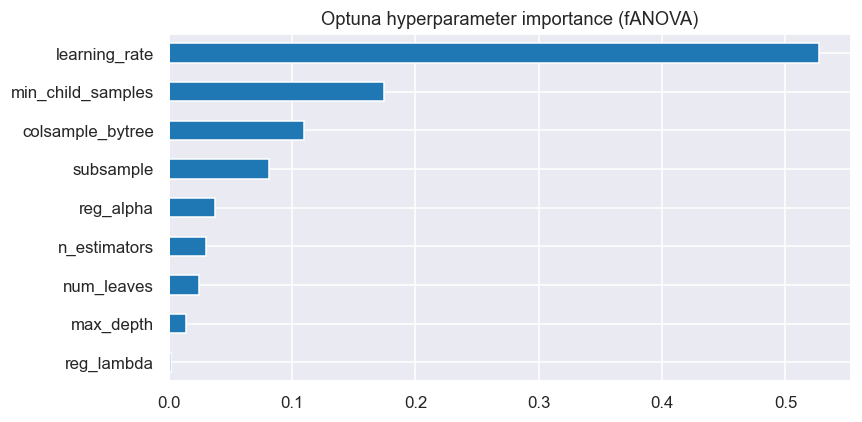

In [18]:
try:
    imp = optuna.importance.get_param_importances(study)
    fig, ax = plt.subplots(figsize=(8, 4))
    pd.Series(imp).sort_values().plot.barh(ax=ax)
    ax.set_title('Optuna hyperparameter importance (fANOVA)')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Could not compute: {e}')

## 7. Final model - train on full train set

In [19]:
final_params = {**study.best_params,
    'device': LGBM_DEVICE, 'gpu_device_id': LGBM_DEVICE_ID,
    'random_state': SEED, 'n_jobs': 1 if LGBM_DEVICE != 'cpu' else -1, 'verbose': -1}
model_sl = lgb.LGBMRegressor(**final_params)
model_tp = lgb.LGBMRegressor(**final_params)
model_sl.fit(X_tr, y_sl_tr); model_tp.fit(X_tr, y_tp_tr)
print('Models trained.')

Models trained.


In [31]:
pred_sl_tr = _clip_predictions(model_sl.predict(X_tr), SL_MIN, SL_MAX)
pred_tp_tr = _clip_predictions(model_tp.predict(X_tr), TP_MIN, TP_MAX)
pred_sl_te = _clip_predictions(model_sl.predict(X_te), SL_MIN, SL_MAX)
pred_tp_te = _clip_predictions(model_tp.predict(X_te), TP_MIN, TP_MAX)

# Bias correction: subtract ~0 pips from predicted SL (model systematically over-predicts)
SL_SHIFT = 0
pred_sl_tr = _clip_predictions(pred_sl_tr - SL_SHIFT, SL_MIN, SL_MAX)
pred_sl_te = _clip_predictions(pred_sl_te - SL_SHIFT, SL_MIN, SL_MAX)

err_sl = pred_sl_te.astype(float) - y_sl_te.astype(float)
err_tp = pred_tp_te.astype(float) - y_tp_te.astype(float)
print(f'SL MAE: {np.abs(err_sl).mean():.2f} pips  bias: {err_sl.mean():+.2f}')
print(f'TP MAE: {np.abs(err_tp).mean():.2f} pips  bias: {err_tp.mean():+.2f}')

SL MAE: 4.70 pips  bias: -0.29
TP MAE: 8.41 pips  bias: -0.23


## 8. Prediction quality vs oracle

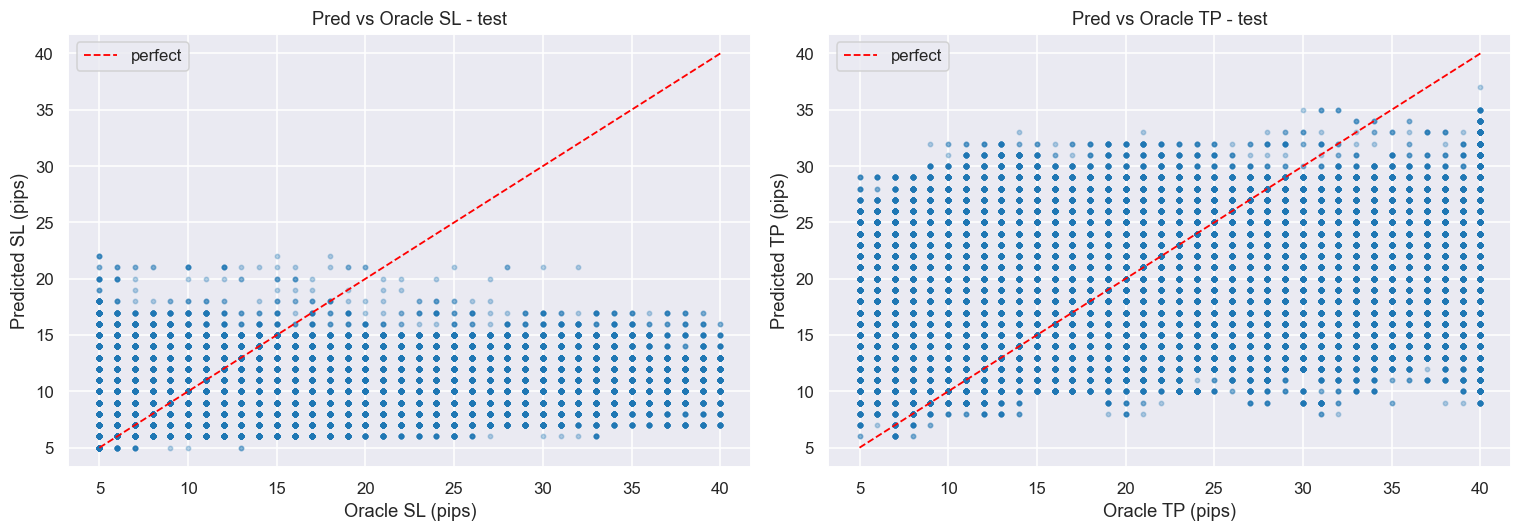

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, oracle, label, lo, hi in [
    (axes[0], pred_sl_te, y_sl_te, 'SL', SL_MIN, SL_MAX),
    (axes[1], pred_tp_te, y_tp_te, 'TP', TP_MIN, TP_MAX)]:
    ax.scatter(oracle, pred, s=8, alpha=0.3)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2, label='perfect')
    ax.set_xlabel(f'Oracle {label} (pips)'); ax.set_ylabel(f'Predicted {label} (pips)')
    ax.set_title(f'Pred vs Oracle {label} - test'); ax.legend()
plt.tight_layout(); plt.show()

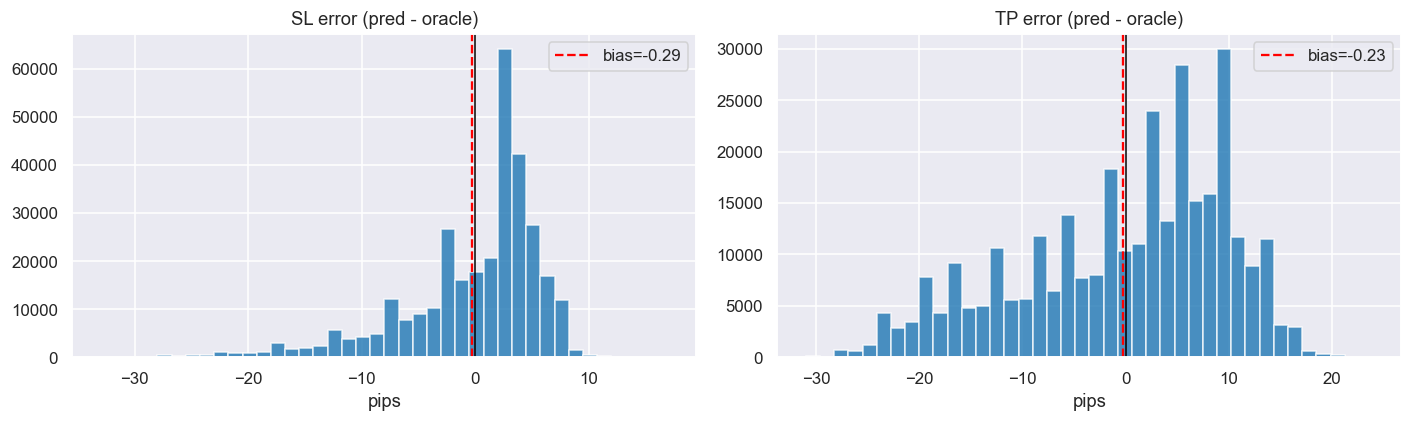

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, err, label in [(axes[0], err_sl, 'SL'), (axes[1], err_tp, 'TP')]:
    ax.hist(err, bins=40, alpha=0.8)
    ax.axvline(0, color='black', lw=1)
    ax.axvline(err.mean(), color='red', lw=1.5, linestyle='--', label=f'bias={err.mean():+.2f}')
    ax.set_title(f'{label} error (pred - oracle)'); ax.set_xlabel('pips'); ax.legend()
plt.tight_layout(); plt.show()

## 9. Simulated PnL comparison

In [34]:
pnl_model  = simulate_per_trade(H_te, L_te, C_te, E_te, SP_te, pred_sl_te, pred_tp_te)
pnl_oracle = simulate_per_trade(H_te, L_te, C_te, E_te, SP_te,
                                y_sl_te.astype(int), y_tp_te.astype(int))
import pathlib as _pl, json as _js
bl_path = _pl.Path(_root) / 'models' / 'session_baseline' / 'metrics.json'
if bl_path.exists():
    bl = _js.loads(bl_path.read_text())
    bl_sl, bl_tp = int(bl['best_sl_pips']), int(bl['best_tp_pips'])
    print(f'Baseline: SL={bl_sl} TP={bl_tp}')
else:
    bl_sl, bl_tp = 20, 30
    print(f'No baseline found, using SL={bl_sl} TP={bl_tp}')
pnl_baseline = simulate(H_te, L_te, C_te, E_te, SP_te, bl_sl, bl_tp)
def _stats(p):
    f = p.flatten(); gp = float(f[f>0].sum()); gl = float(abs(f[f<0].sum()))
    return dict(net_pips=round(float(p.sum()),1), per_trade=round(float(p.sum())/p.size,2),
                win_pct=round(float((f>0).mean())*100,1), pf=round(gp/gl,3) if gl else float('inf'))
summary = pd.DataFrame({
    f'Baseline SL={bl_sl}/TP={bl_tp}': _stats(pnl_baseline),
    'Model predicted': _stats(pnl_model),
    'Oracle ceiling':  _stats(pnl_oracle),
}).T
summary.index.name = 'Strategy'
print(); display(summary)

Baseline: SL=30 TP=6



,net_pips,per_trade,win_pct,pf
Strategy,,,,
Baseline SL=30/TP=6,-879034.1,-1.37,72.4,0.693
Model predicted,-1129501.5,-1.77,36.9,0.727
Oracle ceiling,5181455.5,8.10,70.0,5.097


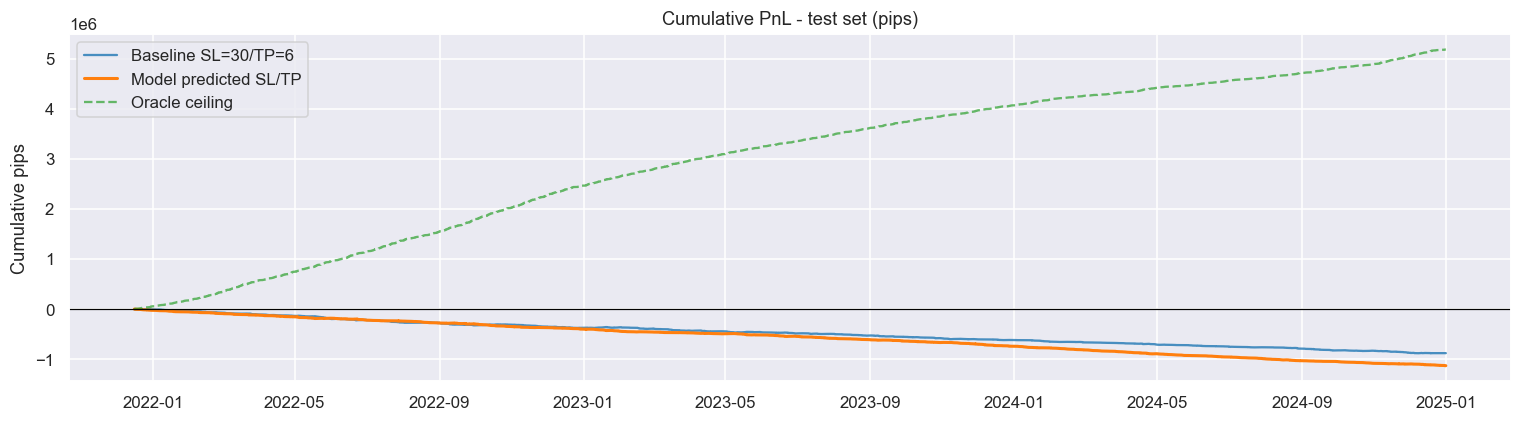

In [35]:
te_ts = pd.DatetimeIndex(df.index[te_pos])
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(te_ts, pnl_baseline.sum(axis=1).cumsum(), label=f'Baseline SL={bl_sl}/TP={bl_tp}', alpha=0.8)
ax.plot(te_ts, pnl_model.sum(axis=1).cumsum(),    label='Model predicted SL/TP', lw=2)
ax.plot(te_ts, pnl_oracle.sum(axis=1).cumsum(),   label='Oracle ceiling', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Cumulative PnL - test set (pips)'); ax.set_ylabel('Cumulative pips'); ax.legend()
plt.tight_layout(); plt.show()

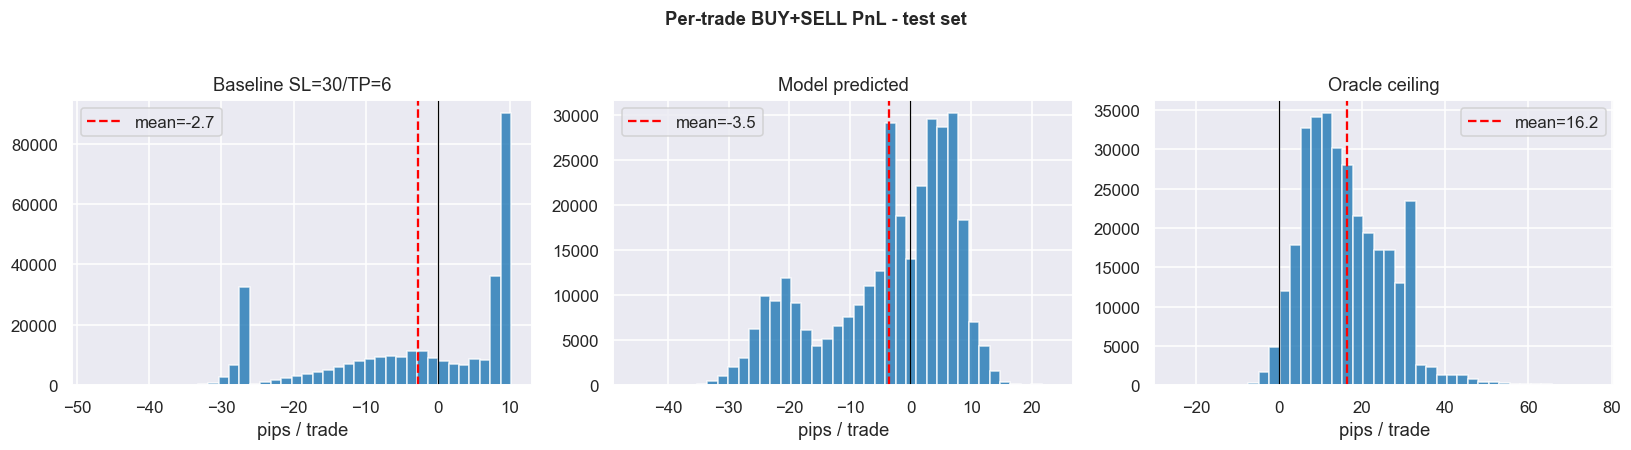

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pnl, label in [
    (axes[0], pnl_baseline.sum(axis=1), f'Baseline SL={bl_sl}/TP={bl_tp}'),
    (axes[1], pnl_model.sum(axis=1),    'Model predicted'),
    (axes[2], pnl_oracle.sum(axis=1),   'Oracle ceiling')]:
    ax.hist(pnl, bins=40, alpha=0.8)
    ax.axvline(pnl.mean(), color='red', lw=1.5, linestyle='--', label=f'mean={pnl.mean():.1f}')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(label); ax.set_xlabel('pips / trade'); ax.legend()
plt.suptitle('Per-trade BUY+SELL PnL - test set', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. PnL breakdown by hour and DOW

In [37]:
te_hours  = np.array(te_ts.hour)
te_dows   = np.array(te_ts.dayofweek)
dow_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}
def breakdown(pnl_2d, labels, lmap=None):
    rows = []
    for lab in sorted(set(labels.tolist())):
        mask = labels == lab; p = pnl_2d[mask].sum(axis=1)
        gp = float(p[p>0].sum()); gl = float(abs(p[p<0].sum()))
        rows.append({'label': lmap[lab] if lmap else lab, 'sessions': int(mask.sum()),
            'net_pips': round(float(p.sum()),1), 'avg_pip': round(float(p.mean()),2),
            'win_pct': round(float((p>0).mean())*100,1),
            'pf': round(gp/gl,3) if gl else float('inf')})
    return pd.DataFrame(rows).set_index('label')
hour_bl = breakdown(pnl_baseline, te_hours)
hour_md = breakdown(pnl_model,    te_hours)
dow_bl  = breakdown(pnl_baseline, te_dows, dow_names)
dow_md  = breakdown(pnl_model,    te_dows, dow_names)

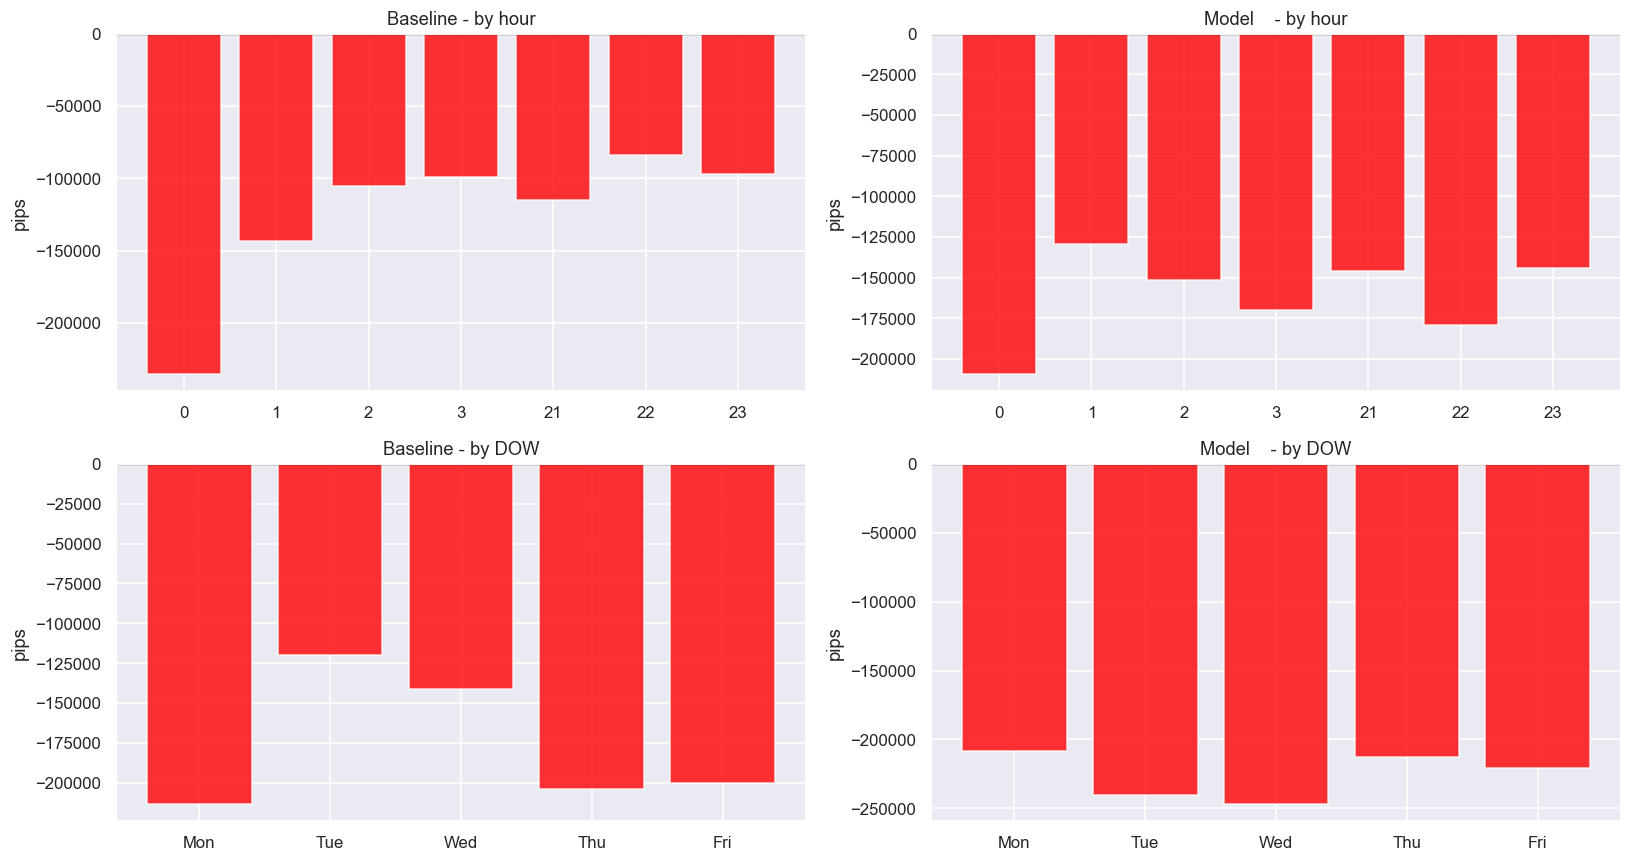

By hour - model:


,sessions,net_pips,avg_pip,win_pct,pf
label,,,,,
0,40011,-209596.8,-5.24,36.0,0.183
1,47279,-129337.4,-2.74,50.7,0.491
2,47300,-151495.8,-3.20,51.4,0.527
3,47340,-170031.5,-3.59,53.1,0.532
21,47160,-145808.3,-3.09,47.0,0.451
22,46969,-179303.7,-3.82,43.7,0.351
23,43660,-143928.0,-3.30,45.5,0.374


By DOW  - model:


,sessions,net_pips,avg_pip,win_pct,pf
label,,,,,
Mon,63007,-208396.5,-3.31,47.2,0.444
Tue,64723,-240341.3,-3.71,45.5,0.395
Wed,64019,-247160.3,-3.86,46.5,0.407
Thu,64638,-212762.5,-3.29,47.7,0.458
Fri,63332,-220840.9,-3.49,48.3,0.426


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, df_p, title in [
    (axes[0,0], hour_bl['net_pips'], 'Baseline - by hour'),
    (axes[0,1], hour_md['net_pips'], 'Model    - by hour'),
    (axes[1,0], dow_bl['net_pips'],  'Baseline - by DOW'),
    (axes[1,1], dow_md['net_pips'],  'Model    - by DOW')]:
    colors = ['green' if v >= 0 else 'red' for v in df_p.values]
    ax.bar(df_p.index.astype(str), df_p.values, color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8); ax.set_title(title); ax.set_ylabel('pips')
plt.tight_layout(); plt.show()
print('By hour - model:'); display(hour_md)
print('By DOW  - model:'); display(dow_md)

## 11. Feature importances

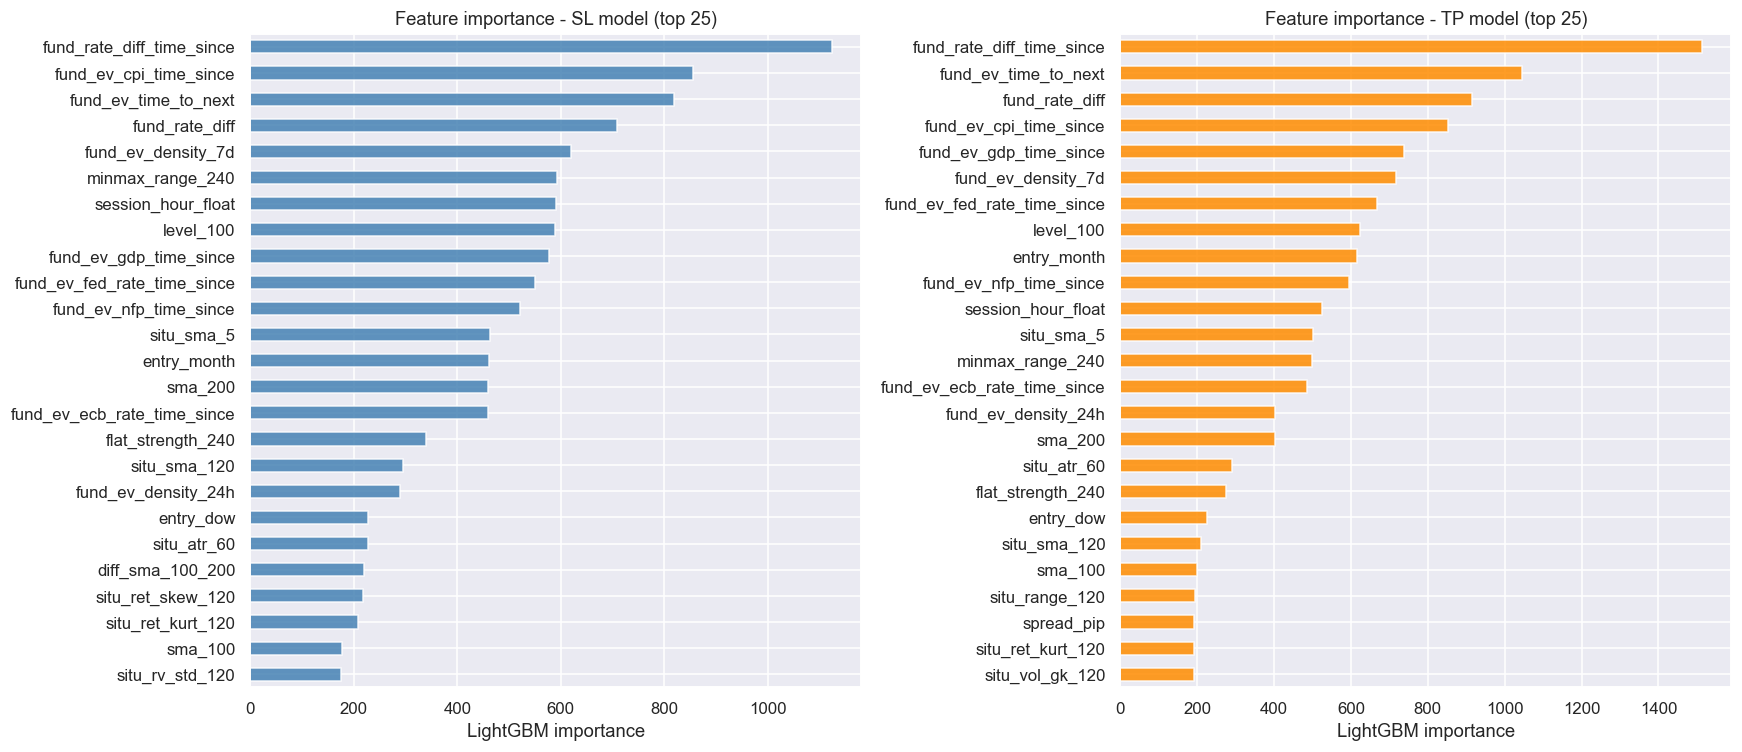

In [39]:
top_n  = 25
imp_sl = pd.Series(model_sl.feature_importances_, index=feature_names).sort_values(ascending=False)
imp_tp = pd.Series(model_tp.feature_importances_, index=feature_names).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, top_n*0.28)))
for ax, imp, label, color in [
    (axes[0], imp_sl, 'SL model', 'steelblue'),
    (axes[1], imp_tp, 'TP model', 'darkorange')]:
    imp.head(top_n).sort_values().plot.barh(ax=ax, color=color, alpha=0.85)
    ax.set_title(f'Feature importance - {label} (top {top_n})')
    ax.set_xlabel('LightGBM importance')
plt.tight_layout(); plt.show()

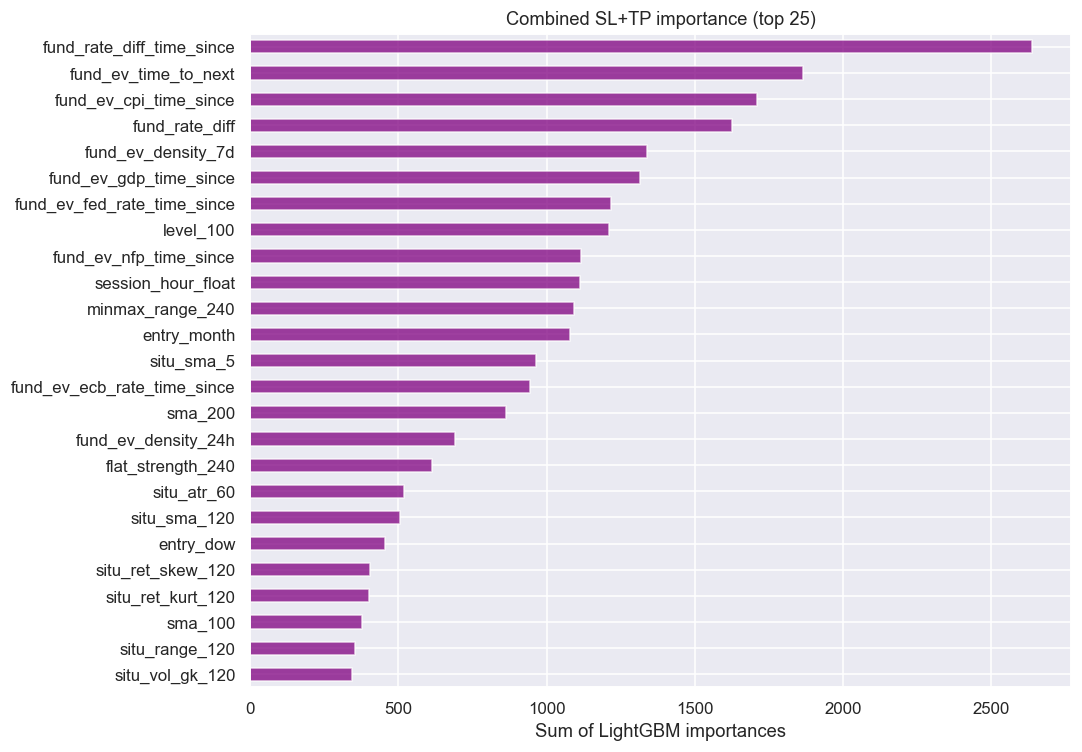

In [40]:
imp_c = (imp_sl + imp_tp).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, max(4, top_n*0.28)))
imp_c.head(top_n).sort_values().plot.barh(ax=ax, color='purple', alpha=0.75)
ax.set_title(f'Combined SL+TP importance (top {top_n})')
ax.set_xlabel('Sum of LightGBM importances')
plt.tight_layout(); plt.show()

## 12. Results summary

In [41]:
sep = '=' * 60
s_bl = _stats(pnl_baseline); s_md = _stats(pnl_model); s_or = _stats(pnl_oracle)
print(sep)
print('  SL/TP Regressor - Exploration Summary')
print(sep)
print(f'  Subset        : {SUBSET_START} -> {SUBSET_END}')
print(f'  Feature set   : {FEATURE_SET}  |  Device : {LGBM_DEVICE}')
print(f'  Session hours : {SESSION_HOURS} UTC')
print(f'  Train entries : {len(tr_pos):,}  |  Test: {len(te_pos):,}')
print(f'  Features      : {X_tr.shape[1]}')
print(f'  Best CV PnL   : {study.best_value:+,.1f} pips (mean val-fold)')
print()
print(f'  Baseline : {s_bl["net_pips"]:>10,.1f} pips | {s_bl["per_trade"]:+.2f}/trade | PF={s_bl["pf"]}')
print(f'  Model    : {s_md["net_pips"]:>10,.1f} pips | {s_md["per_trade"]:+.2f}/trade | PF={s_md["pf"]}')
print(f'  Oracle   : {s_or["net_pips"]:>10,.1f} pips | {s_or["per_trade"]:+.2f}/trade | PF={s_or["pf"]}')
print(f'  SL MAE   : {np.abs(err_sl).mean():.2f} pips  |  TP MAE: {np.abs(err_tp).mean():.2f} pips')
print(sep)

  SL/TP Regressor - Exploration Summary
  Subset        : 2010-01-01 -> 2024-12-31
  Feature set   : all  |  Device : cpu
  Session hours : [21, 22, 23, 0, 1, 2, 3] UTC
  Train entries : 1,278,872  |  Test: 319,719
  Features      : 184
  Best CV PnL   : -555,120.0 pips (mean val-fold)

  Baseline : -879,034.1 pips | -1.37/trade | PF=0.693
  Model    : -1,129,501.5 pips | -1.77/trade | PF=0.727
  Oracle   : 5,181,455.5 pips | +8.10/trade | PF=5.097
  SL MAE   : 4.70 pips  |  TP MAE: 8.41 pips
